In [2]:
import zipfile
import os

zip_file = "archive.zip"

extract_folder = "dataset"

if not os.path.exists(extract_folder):
    with zipfile.ZipFile(zip_file, 'r') as zip_ref:
        zip_ref.extractall(extract_folder)

print("Dataset Extracted Successfully!")

Dataset Extracted Successfully!


In [4]:
import os

for root, dirs, files in os.walk("dataset"):
    print(root)

dataset
dataset\brain_tumor_dataset
dataset\brain_tumor_dataset\no
dataset\brain_tumor_dataset\yes
dataset\no
dataset\yes


In [6]:
dataset_path = "dataset/brain_tumor_dataset"

In [8]:
import os

print("No Images :", len(os.listdir("dataset/brain_tumor_dataset/no")))
print("Yes Images:", len(os.listdir("dataset/brain_tumor_dataset/yes")))

No Images : 98
Yes Images: 155


In [12]:
import os
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.utils import to_categorical

In [14]:
dataset_path = "dataset/brain_tumor_dataset"

X = []
y = []

categories = ["no", "yes"]

for label, category in enumerate(categories):

    folder = os.path.join(dataset_path, category)

    for image_name in os.listdir(folder):

        image_path = os.path.join(folder, image_name)

        try:
            img = Image.open(image_path).convert("RGB")
            img = img.resize((128,128))
            img = np.array(img)

            X.append(img)
            y.append(label)

        except:
            continue

In [16]:
X = np.array(X, dtype="float32")
y = np.array(y)

print("Images Shape:", X.shape)
print("Labels Shape:", y.shape)

Images Shape: (253, 128, 128, 3)
Labels Shape: (253,)


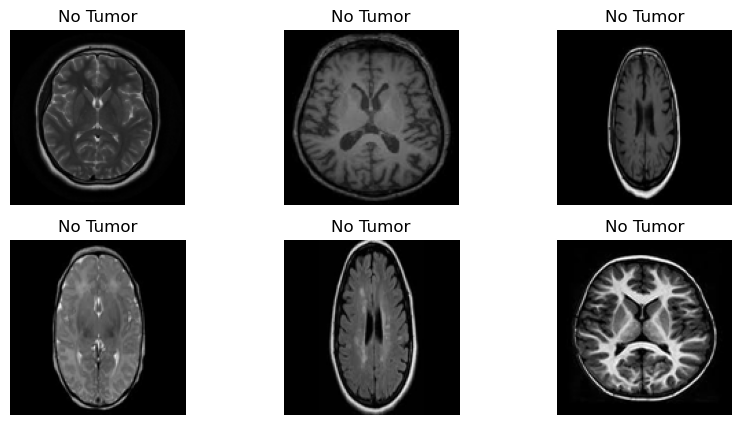

In [18]:
plt.figure(figsize=(10,5))

for i in range(6):

    plt.subplot(2,3,i+1)

    plt.imshow(X[i].astype("uint8"))

    if y[i] == 0:
        plt.title("No Tumor")
    else:
        plt.title("Tumor")

    plt.axis("off")

plt.show()

In [20]:
X = X / 255.0

In [22]:
y = to_categorical(y, 2)

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Images:", len(X_train))
print("Testing Images:", len(X_test))

Training Images: 202
Testing Images: 51


In [26]:
model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D((2,2)))

model.add(Flatten())

model.add(Dense(128, activation='relu'))

model.add(Dense(2, activation='softmax'))

C:\Users\Jhanvi\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [28]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [30]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 126, 126, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 57600)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       7,372,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 2)                   │             258 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 7,392,578 (28.20 MB)

 Trainable params: 7,392,578 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

In [32]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=16,
    validation_data=(X_test, y_test)
)

Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 285ms/step - accuracy: 0.6337 - loss: 1.0227 - val_accuracy: 0.8824 - val_loss: 0.4333
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 178ms/step - accuracy: 0.7871 - loss: 0.4988 - val_accuracy: 0.8824 - val_loss: 0.3707
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 193ms/step - accuracy: 0.8366 - loss: 0.3989 - val_accuracy: 0.9216 - val_loss: 0.2884
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 185ms/step - accuracy: 0.9257 - loss: 0.2575 - val_accuracy: 0.9020 - val_loss: 0.2697
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 167ms/step - accuracy: 0.9505 - loss: 0.1338 - val_accuracy: 0.9020 - val_loss: 0.2695
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 174ms/step - accuracy: 0.9901 - loss: 0.0629 - val_accuracy: 0.9020 - val_loss: 0.2709
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 205ms/step - accuracy: 1.0000 - loss: 0.0213 - val_accuracy: 0.9020 - val_loss: 0.3543
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 204ms/step - accuracy: 0.9950 - loss: 0.0134 - val_accuracy: 0.

In [33]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - accuracy: 0.9216 - loss: 0.5507
Test Loss: 0.5507274866104126
Test Accuracy: 0.9215686321258545


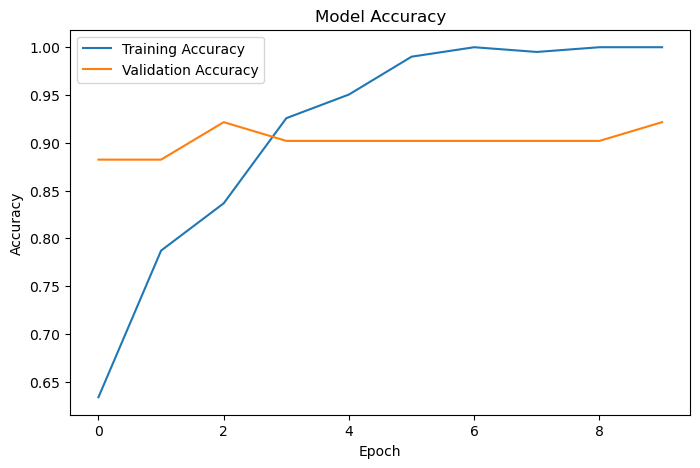

In [34]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()

plt.show()

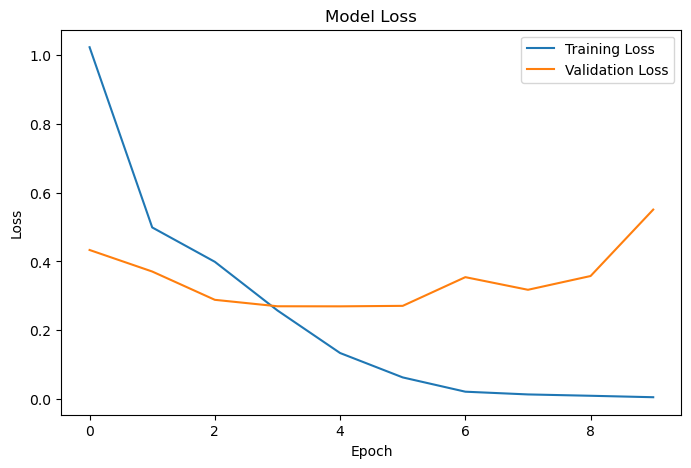

In [38]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.show()

In [40]:
predictions = model.predict(X_test)

predicted_labels = np.argmax(predictions, axis=1)
true_labels = np.argmax(y_test, axis=1)

cm = confusion_matrix(true_labels, predicted_labels)

print("Confusion Matrix")
print(cm)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step
Confusion Matrix
[[16  4]
 [ 0 31]]


In [42]:
print(classification_report(
    true_labels,
    predicted_labels,
    target_names=["No Tumor", "Tumor"]
))

              precision    recall  f1-score   support

    No Tumor       1.00      0.80      0.89        20
       Tumor       0.89      1.00      0.94        31

    accuracy                           0.92        51
   macro avg       0.94      0.90      0.91        51
weighted avg       0.93      0.92      0.92        51



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step


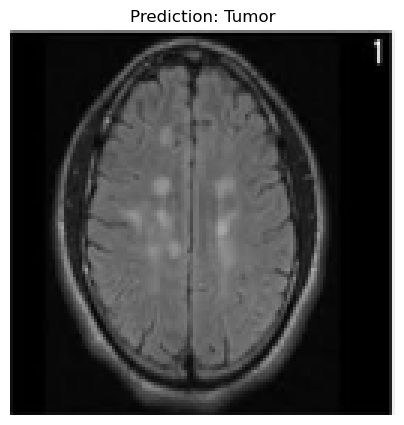

In [44]:
index = np.random.randint(len(X_test))

image = X_test[index]

prediction = model.predict(np.expand_dims(image, axis=0))

predicted_class = np.argmax(prediction)

labels = ["No Tumor", "Tumor"]

plt.figure(figsize=(5,5))
plt.imshow(image)
plt.title("Prediction: " + labels[predicted_class])
plt.axis("off")
plt.show()

In [46]:
''' 
conclusion
The CNN-based brain MRI image classification model was successfully developed to detect the presence of a brain tumor. The model achieved a test accuracy of 92.16% with a test loss of 0.5507, indicating good overall performance on unseen MRI images. The classification report shows that the model achieved a precision of 100% for the No Tumor class and 88.6% for the Tumor class, while the recall was 80% for No Tumor and 100% for Tumor. This demonstrates that the model was highly effective at identifying tumor cases, although a few healthy images were incorrectly classified as tumors.

Overall, the results indicate that the CNN model is capable of accurately distinguishing between tumor and non-tumor MRI images, achieving an overall F1-score of 0.92. While the model performs well, its accuracy could be further improved by training on a larger dataset, applying data augmentation, or using transfer learning techniques such as VGG16 or ResNet. This project demonstrates the potential of deep learning techniques in assisting the early detection of brain tumors from MRI scans.'''

' \nconclusion\nThe CNN-based brain MRI image classification model was successfully developed to detect the presence of a brain tumor. The model achieved a test accuracy of 92.16% with a test loss of 0.5507, indicating good overall performance on unseen MRI images. The classification report shows that the model achieved a precision of 100% for the No Tumor class and 88.6% for the Tumor class, while the recall was 80% for No Tumor and 100% for Tumor. This demonstrates that the model was highly effective at identifying tumor cases, although a few healthy images were incorrectly classified as tumors.\n\nOverall, the results indicate that the CNN model is capable of accurately distinguishing between tumor and non-tumor MRI images, achieving an overall F1-score of 0.92. While the model performs well, its accuracy could be further improved by training on a larger dataset, applying data augmentation, or using transfer learning techniques such as VGG16 or ResNet. This project demonstrates the 